# Country Prediction from Street View Images - ResNet50

In [1]:
# Dependencies
%pip install -q torch torchvision
%pip install -q pycountry tqdm matplotlib seaborn tensorboard kagglehub timm evaluate grad-cam scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Hyperparameters

In [2]:
import random
import numpy as np
import torch

# Set random seeds
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

NUM_EPOCHS = 5
BATCH_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LEARNING_RATE = 1e-4
LR_SCHEDULER_PATIENCE = 2
LR_SCHEDULER_FACTOR = 0.1
EARLY_STOPPING_PATIENCE = 3
LOG_DIR = "runs/vit"
CHECKPOINT_DIR = "model"

print(f"Using device: {DEVICE}")
print(f"Seed set to: {RANDOM_SEED}")
print(f"Num epochs: {NUM_EPOCHS}, Batch size: {BATCH_SIZE}, Learning rate: {LEARNING_RATE}")
print(f"TensorBoard log dir: {LOG_DIR}")
print(f"Model checkpoint dir: {CHECKPOINT_DIR}")

Using device: cuda
Seed set to: 42
Num epochs: 5, Batch size: 64, Learning rate: 0.0001
TensorBoard log dir: runs/vit
Model checkpoint dir: model


## Data Preparation

- Create and load dataset
- Put data in correct format -> labels list, where each class is associated with one country
- Stratified split into training, validation, test sets (80/10/10)

In [3]:
import torch
import os
from torchvision import transforms
from src.dataset import StreetViewDataset


DATASET_DIR = "./data"

transform = transforms.Compose([
  transforms.Resize((224, 224)),
  transforms.ToTensor()
])

dataset = StreetViewDataset(DATASET_DIR, transform=transform)

In [4]:
import numpy as np
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from collections import Counter

TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.1

label_map = dataset.label_map  
rev_label_map = {v: k for k, v in label_map.items()}  

labels = [rev_label_map[dataset.samples[i][1]] for i in range(len(dataset))]

indices = np.arange(len(dataset))
train_idx, temp_idx, _, _ = train_test_split(
    indices, labels, train_size=TRAIN_SPLIT, stratify=labels,
    random_state=RANDOM_SEED
)

temp_labels = [labels[i] for i in temp_idx]
val_ratio_from_remaining = VAL_SPLIT / (1 - TRAIN_SPLIT)
val_idx, test_idx, _, _ = train_test_split(
    temp_idx, temp_labels, train_size=val_ratio_from_remaining, 
    stratify=temp_labels, random_state=RANDOM_SEED
)

train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)
test_set = Subset(dataset, test_idx)

all_countries = set(labels)
train_countries = set(labels[i] for i in train_idx)
val_countries = set(labels[i] for i in val_idx)
test_countries = set(labels[i] for i in test_idx)

print(f"\nTrain samples: {len(train_set)} (missing: {all_countries - train_countries})")
print(f"Val samples: {len(val_set)} (missing: {all_countries - val_countries})")
print(f"Test samples: {len(test_set)} (missing: {all_countries - test_countries})")

train_loader = DataLoader(train_set, BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, BATCH_SIZE)
test_loader = DataLoader(test_set, BATCH_SIZE)


Train samples: 123079 (missing: set())
Val samples: 15385 (missing: set())
Test samples: 15385 (missing: set())


## Model

### Base Vision Transformer (ViT) - [Docs](https://huggingface.co/docs/transformers/model_doc/vit)
- Transformer for computer vision tasks
- Splits images into fixed-sized patches, treating them as a sequence of tokens

In [5]:
import torch.nn as nn

num_classes = len(dataset.label_map)
print(num_classes)

107


In [6]:
from src.model import ViTModel

model = ViTModel(num_classes, pretrained=True)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

/home/jovyan/CountryGuessr/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Training/Validation

### Logging
- Log training loss and accuracy during training phase
- Compute and log validation loss, accuracy, precision, recall, and F1-Score
- Generate and log confusion matrix heatmap images
- Visualize all metrics and images using TensorBoard

### Learning Rate Scheduler
- "ReduceLROnPlateau" scheduler to reduce learning rate when validation loss plateaus
- Helps to fine-tune training progression and prevent getting stuck in local minima

### Early Stopping
- Monitor validation loss to detect noo improvement over specified patience period
- Stops training early if no improvement is observed

### Checkpoint Saving
- Save model checkpoints at the end of each epoch
- Update a dedicated "best" checkpoint whenever validation loss improves

In [7]:
import os
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns
import io
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.tensorboard import SummaryWriter
from src.train import train_epoch, validate_epoch, save_checkpoint

scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=LR_SCHEDULER_FACTOR, patience=LR_SCHEDULER_PATIENCE)
writer = SummaryWriter(LOG_DIR)

# Load metrics
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")
confusion_metric = evaluate.load("confusion_matrix")

def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(10, 10))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format="png")
    buf.seek(0)
    plt.close()

    image = plt.imread(buf)
    buf.close()
    return image

global_step = 0
best_val_loss = float("inf")
epochs_without_improvement = 0

print(f"Using {model.__class__.__name__}")
for epoch in range(NUM_EPOCHS):
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")

    # Train/Val
    train_loss, train_acc, global_step = train_epoch(model, train_loader, criterion, optimizer, DEVICE, writer, global_step)
    val_loss, val_acc, val_preds, val_labels, global_step = validate_epoch(model, val_loader, criterion, DEVICE, writer, global_step)

    # Quantitative Metrics
    precision_metric.add_batch(predictions=val_preds, references=val_labels)
    val_precision = precision_metric.compute(average="macro")["precision"]

    recall_metric.add_batch(predictions=val_preds, references=val_labels)
    val_recall = recall_metric.compute(average="macro")["recall"]
    
    f1_metric.add_batch(predictions=val_preds, references=val_labels)
    val_f1 = f1_metric.compute(average="macro")["f1"]

    confusion_metric.add_batch(predictions=val_preds, references=val_labels)
    cm_result = confusion_metric.compute()["confusion_matrix"]
    cm_image = plot_confusion_matrix(cm_result, dataset.label_map)
    cm_tensor = transforms.ToTensor()(cm_image).unsqueeze(0)

    # Tensorboard logging
    writer.add_scalar("Validation/Precision", val_precision, epoch)
    writer.add_scalar("Validation/Recall", val_recall, epoch)
    writer.add_scalar("Validation/F1-Score", val_f1, epoch)
    writer.add_image("Validation/Confusion_Matrix", cm_tensor[0], epoch)

    # Learning rate scheduler
    scheduler.step(val_loss)

    # Store checkpoint after epoch
    save_checkpoint(model, optimizer, epoch, dataset.label_map, train_loss=train_loss, val_loss=val_loss, train_acc=train_acc, val_acc=val_acc, checkpoint_dir=os.path.join(CHECKPOINT_DIR, model.__class__.__name__))
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - train_loss={train_loss:.4f}, train_acc={train_acc:.4f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        # Update best checkpoint if val_loss decreases
        save_checkpoint(model, optimizer, epoch, dataset.label_map, train_loss=train_loss, val_loss=val_loss, train_acc=train_acc, val_acc=val_acc, checkpoint_dir=os.path.join(CHECKPOINT_DIR, model.__class__.__name__), filename="best.pth")
        print(f"Best model updated at Epoch {epoch+1} with val_loss={val_loss:.4f}")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"No improvement for {EARLY_STOPPING_PATIENCE} epochs. Early stopping.")
        break

Using ViTModel
Epoch 1/5


Checkpoint saved to model/ViTModel/epoch_0.pth
Epoch 1/5 - train_loss=1.8649, train_acc=0.4840
Checkpoint saved to model/ViTModel/best.pth
Best model updated at Epoch 1 with val_loss=1.2245
Epoch 2/5


Checkpoint saved to model/ViTModel/epoch_1.pth
Epoch 2/5 - train_loss=0.9209, train_acc=0.7184
Checkpoint saved to model/ViTModel/best.pth
Best model updated at Epoch 2 with val_loss=0.9867
Epoch 3/5


Checkpoint saved to model/ViTModel/epoch_2.pth
Epoch 3/5 - train_loss=0.5736, train_acc=0.8199
Checkpoint saved to model/ViTModel/best.pth
Best model updated at Epoch 3 with val_loss=0.9789
Epoch 4/5


Checkpoint saved to model/ViTModel/epoch_3.pth
Epoch 4/5 - train_loss=0.3652, train_acc=0.8809
Epoch 5/5


Checkpoint saved to model/ViTModel/epoch_4.pth
Epoch 5/5 - train_loss=0.2601, train_acc=0.9138


In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs/

## Inferencing
Models are inferenced on whole test set quantitatively and qualitatively on single images

### Load model

In [7]:
import torch
from src.model import ViTModel

checkpoint = torch.load('model/ViTModel/best.pth')
model = ViTModel(num_classes=len(checkpoint["label_map"]), pretrained=False)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

ViTModel(
  (vit): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): G

### Inference on whole test set
- Creates a csv with the image filenames, the ground-truth labels, and the predicted labels
- Used for further analyzation to detect weaknesses, strengths, ...

In [8]:
from src.evaluation import inference
import pandas as pd

test_images, test_preds, test_labels = inference(model, test_loader, dataset.label_map, DEVICE)

results_df = pd.DataFrame({
    "image": test_images,
    "ground_truth": test_labels,
    "prediction": test_preds
})

results_df.to_csv("model/vit.csv", index=False)
print(f"Saved inference results for {len(test_preds)} samples to model/vit.csv")

Saved inference results for 15385 samples to model/vit.csv


### Inference single image
- Inferences single, random images from the test set
- Qualitative evaluation over model predictions
- Grad-CAM heatmaps to visualize parts of image the prediction is based on - [Docs](https://github.com/jacobgil/pytorch-grad-cam/tree/master)

Predicted probabilities:
Andorra: 99.73%
Chile: 0.10%
Canada: 0.06%
Korea, Republic of: 0.03%
Japan: 0.02%


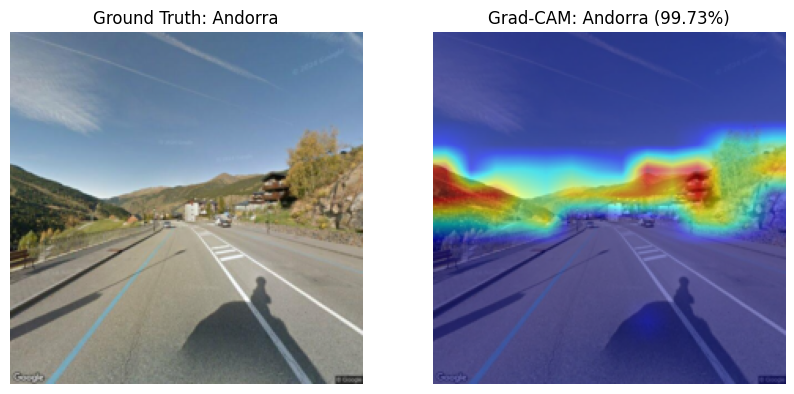

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def reshape_transform(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

target_layers = [model.vit.blocks[-1].norm1]

# idx = random.randint(0, len(test_set) - 1)
idx = 192
top_k = 5

model.eval()
image, label, image_path = dataset[idx]
image_tensor = image.unsqueeze(0).to(DEVICE) 

with torch.no_grad():
    outputs = model(image_tensor)
    probabilities = torch.softmax(outputs, dim=1).cpu().numpy()[0]

topk_indices = probabilities.argsort()[-top_k:][::-1]
topk_probs = probabilities[topk_indices]

idx_to_name = {v: k for k, v in dataset.label_map.items()}
topk_countries = [idx_to_name[i] for i in topk_indices]

gt_country = idx_to_name[label]

# Grad-CAM
cam = GradCAM(model=model, target_layers=target_layers, reshape_transform=reshape_transform)
targets = [ClassifierOutputTarget(topk_indices[0])]
grayscale_cam = cam(input_tensor=image_tensor, targets=targets)[0]

input_image = image.permute(1, 2, 0).cpu().numpy()
input_image = (input_image - input_image.min()) / (input_image.max() - input_image.min())

cam_image = show_cam_on_image(input_image, grayscale_cam, use_rgb=True)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(input_image)
axs[0].axis('off')
axs[0].set_title(f"Ground Truth: {gt_country}")

axs[1].imshow(cam_image)
axs[1].axis('off')
axs[1].set_title(f"Grad-CAM: {topk_countries[0]} ({topk_probs[0]*100:.2f}%)")

print("Predicted probabilities:")
for country, prob in zip(topk_countries, topk_probs):
    print(f"{country}: {prob*100:.2f}%")